Silhouette scores: {3: np.float64(0.539165051861495), 4: np.float64(0.4695601965044253), 5: np.float64(0.4407972080521641)}
Bästa k: 3


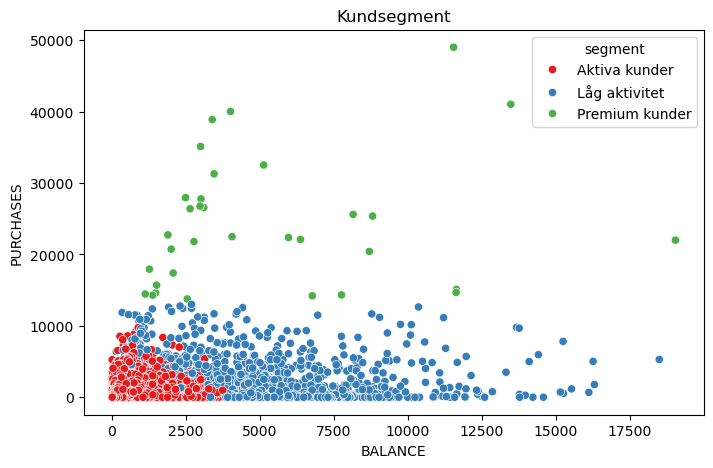

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import os

os.environ["LOKY_MAX_CPU_COUNT"] = "4"

# 1. Läs in data
df = pd.read_excel("bank_data.xlsx")

# 2. Välj variabler (ändra vid behov)
X = df[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']]

# 3. Fylll i inget värde med 0 värde
X = X.fillna(0)

# 4. Skala data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Hitta bästa antal kluster (3–5)
scores = {}
for k in range(3, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)

print("Silhouette scores:", scores)

best_k = max(scores, key=scores.get)
print("Bästa k:", best_k)

# 6. Träna modell
kmeans = KMeans(n_clusters=best_k, random_state=42)
df = df.loc[X.index]
df['cluster'] = kmeans.fit_predict(X_scaled)

# 7. Namnge kluster
cluster_names = {
    0: "Låg aktivitet",
    1: "Aktiva kunder",
    2: "Premium kunder",
    3: "Mycket hög aktivitet",
    4: "Speciella kunder"
}

df['segment'] = df['cluster'].map(cluster_names)

# Sparar filen till csv
df.to_csv("bank_clustered.csv", index=False)

# 8. Visualisering
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='BALANCE', y='PURCHASES', hue='segment', palette='Set1')
plt.title("Kundsegment")
plt.show()